In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sourse_new
plt.rcParams["font.size"] = 14

In [3]:
x_length = 0.02  # x方向の長さ m
y_length = 0.04  # y方向の長さ m
mesh_length = 1.0e-5  # m
nx = int(x_length / mesh_length)  # how many mesh
ny = int(y_length / mesh_length)

dx = x_length / nx  # mesh length m
dy = y_length / ny  # m

rho = 7840  # density kg/m^3
E = 206 * 1e9  # young percentage kg/ms^2
G = 80 * 1e9  # stiffness
V = 0.27  # poisson ratio

cl = np.sqrt(E / rho * (1 - V) / (1 + V) / (1 - 2 * V))  # P wave
ct = np.sqrt(G / rho)  # S wave
c11 = E * (1 - V) / (1 + V) / (1 - 2 * V)
c13 = E * V / (1 + V) / (1 - 2 * V)
c55 = (c11 - c13) / 2

dt = dx / cl / np.sqrt(6)  # time mesh
f = 4.7e6  # frequency
T = 1 / f  # period
lam = cl / f  # lambda
k = 1 / lam  # wave number
n = T / dt  # 波が離散点上で何点か

t_max = 4 * x_length / cl / dt  # 1往復ちょいの時間
wave = np.zeros(int(t_max))
# 傷の幅 m
f_width = 0.25e-3  # m
# 傷の間隔 m
f_pitch = 2.00e-3
# 傷の深さ m
f_depth = 0.10e-3 # m

print(f"f_pitch = {f_pitch}")
print(f"f_depth = {f_depth}")
#  傷の数
num_f = int(y_length / f_pitch)
#  傷の幅の離散点数
mn_w = int(f_width / mesh_length)
#  1ピッチの離散点数
mn_p = int(f_pitch / mesh_length)
# 傷のない部分の離散点数
mn_nf = int((f_pitch - f_width) / mesh_length)
# 傷の深さ方向の離散点数
mn_d = int(f_depth / mesh_length)

f_pitch = 0.002
f_depth = 0.0001


In [9]:
t = np.zeros(int(100))
len(t[0:50])

50

In [7]:
mn_p+mn_w

225

In [4]:
smooth = sourse_new.kiritori2(sourse_new.import_data(0, 0)[0], sourse_new.left, sourse_new.right)
rough = sourse_new.kiritori2(sourse_new.import_data(125, 20)[0], sourse_new.left, sourse_new.right)

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_50.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_51.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_52.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5

In [2]:
sim_ref = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
sim_rough = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth20.csv")
smooth_sim = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_ref[9000:]), sourse_new.left, sourse_new.right)
rough_sim = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough[9000:]), sourse_new.left, sourse_new.right)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


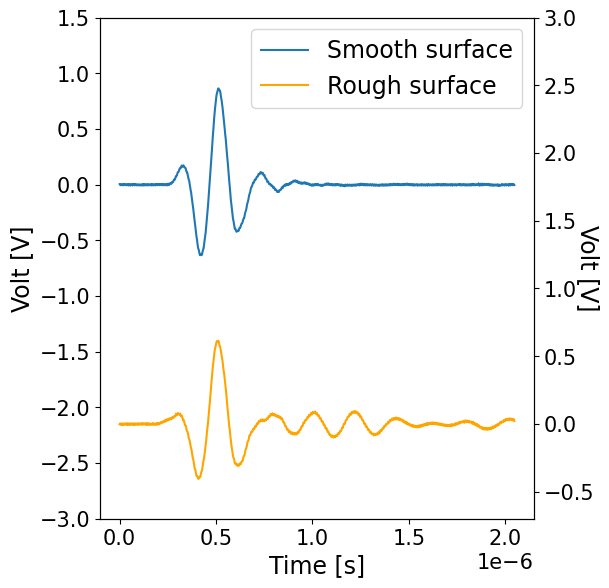

In [7]:
plt.rcParams["font.size"] = 15
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt*len(smooth), sourse_new.exp_dt)

p1, = ax.plot(t, smooth, label='Smooth surface')
p2, = twin1.plot(t, rough, label='Rough surface', color="orange")
fig.tight_layout()
ax.set_ylim(-3.0, 1.5)
twin1.set_ylim(-0.7, 3)

# 軸ラベルのサイズを17に設定
ax.set_xlabel('Time [s]', fontsize=17)
ax.set_ylabel('Volt [V]', fontsize=17)
twin1.set_ylabel('Volt [V]', rotation=270, fontsize=17)

# 凡例のサイズを17に設定
ax.legend(handles=[p1, p2], fontsize=17)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure5a.eps", format="eps", dpi=300)
plt.show()

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_50.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_51.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_52.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_58.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_59.csv


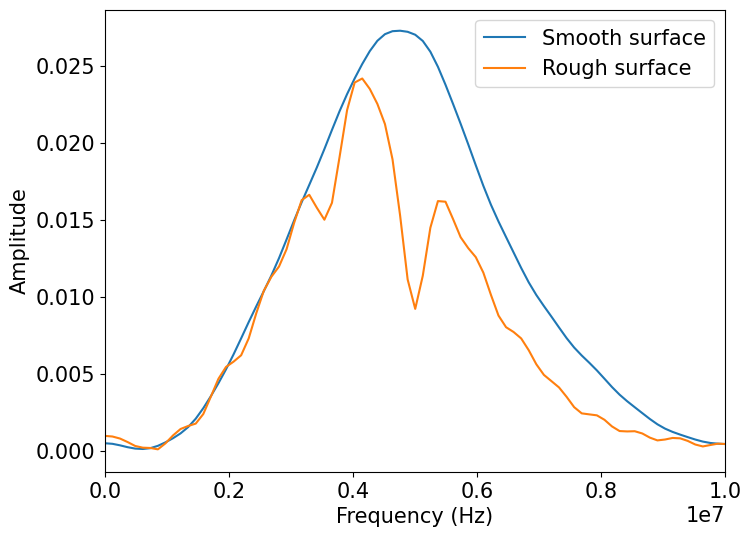

In [26]:
yf_smooth, freq = sourse_new.make_fftdata(sourse_new.kiritori2(sourse_new.import_data(0,0)[0], sourse_new.left, sourse_new.right), sourse_new.exp_dt)
yf_rough, frq = sourse_new.make_fftdata(sourse_new.kiritori2(sourse_new.import_data(125,20)[0], sourse_new.left, sourse_new.right), sourse_new.exp_dt)
plt.figure(figsize=(8, 6))
plt.plot(freq, yf_smooth, label="Smooth surface")
plt.plot(freq, yf_rough, label="Rough surface")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.xlim(0, 10e6)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure6a.eps", format="eps", dpi=300)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


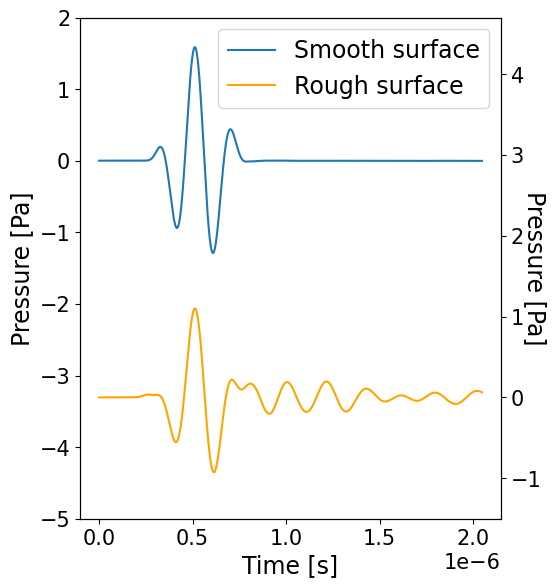

In [5]:
plt.rcParams["font.size"] = 15  # 基本サイズは15のまま
fig, ax = plt.subplots(figsize=(6, 6))
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt*len(smooth), sourse_new.exp_dt)

p1, = ax.plot(t, smooth_sim, label='Smooth surface')
p2, = twin1.plot(t, rough_sim, label='Rough surface', color="orange")
fig.tight_layout()
ax.set_ylim(-5, 2)
twin1.set_ylim(-1.5, 4.7)

# 軸ラベルのサイズを17に設定
ax.set_xlabel('Time [s]', fontsize=17)
ax.set_ylabel('Pressure [Pa]', fontsize=17)
twin1.set_ylabel('Pressure [Pa]', rotation=270, fontsize=17)

# 凡例のサイズを17に設定
ax.legend(handles=[p1, p2], fontsize=17)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure5b.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


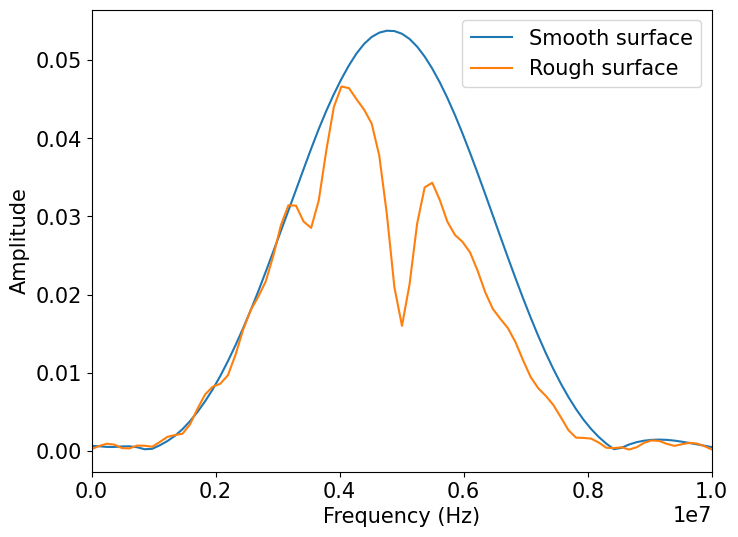

In [28]:
yf_smooth, freq = sourse_new.make_fftdata(sourse_new.kiritori2(smooth_sim, sourse_new.left, sourse_new.right), sourse_new.exp_dt)
yf_rough, frq = sourse_new.make_fftdata(sourse_new.kiritori2(rough_sim, sourse_new.left, sourse_new.right), sourse_new.exp_dt)
plt.figure(figsize=(8, 6))
plt.plot(freq, yf_smooth, label="Smooth surface")
plt.plot(freq, yf_rough, label="Rough surface")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.xlim(0, 10e6)
plt.savefig(r"C:\Users\manat\project2\drawing\sice\Figure6b.eps", format="eps", dpi=300)

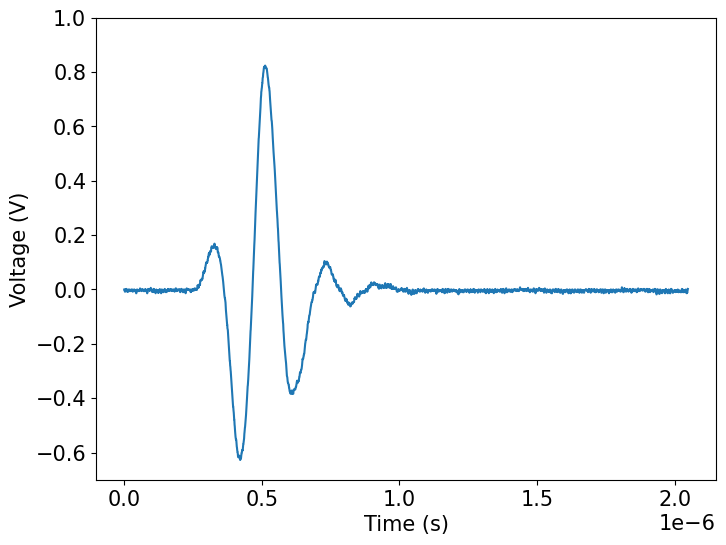

In [3]:
sourse.image_wave(sourse.kiritori2(sourse.import_data(0,10,1)[0], sourse.left, sourse.right), sourse.exp_dt)

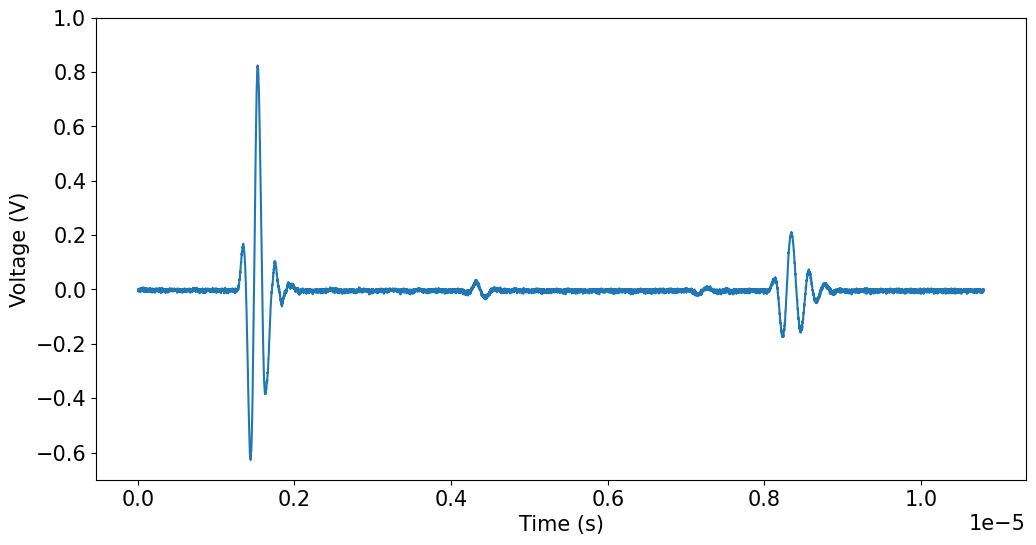

In [3]:
sourse.image_wave(sourse.import_data(0,10,1)[0], sourse.exp_dt)

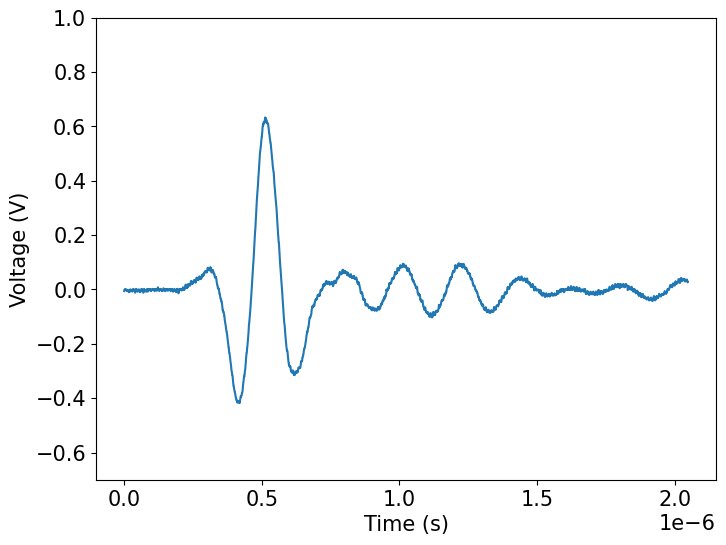

In [4]:
sourse.image_wave(sourse.kiritori2(sourse.import_data(80,10,1)[0], sourse.left, sourse.right), sourse.exp_dt)

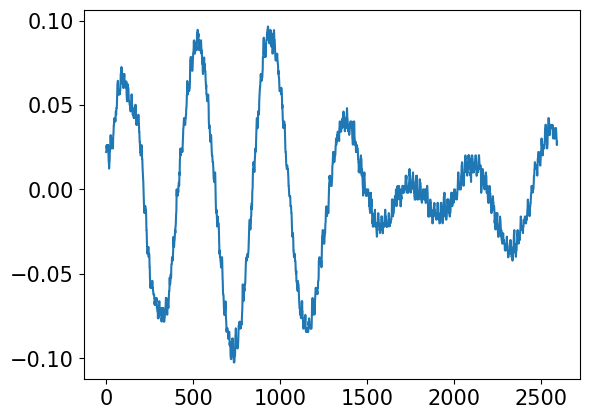

In [5]:
plt.plot(sourse.kiritori2(sourse.import_data(80,10,1)[0], sourse.left, sourse.right)[1500:])

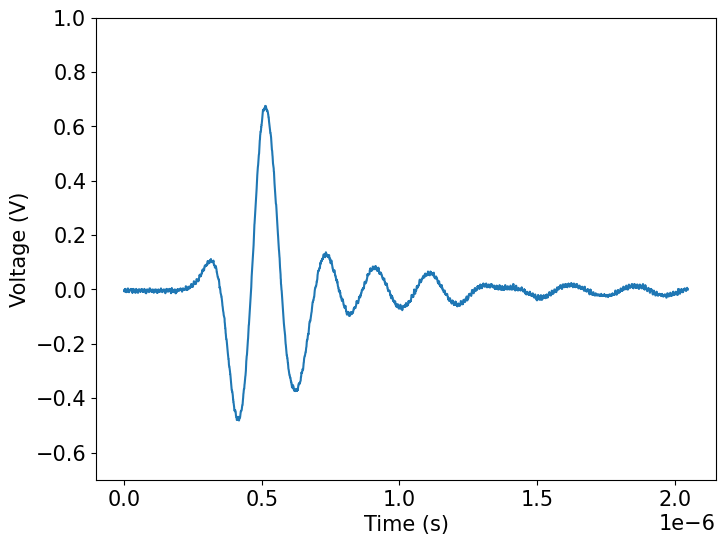

In [6]:
sourse.image_wave(sourse.kiritori2(sourse.import_data(90,10,2)[0], sourse.left, sourse.right), sourse.exp_dt)

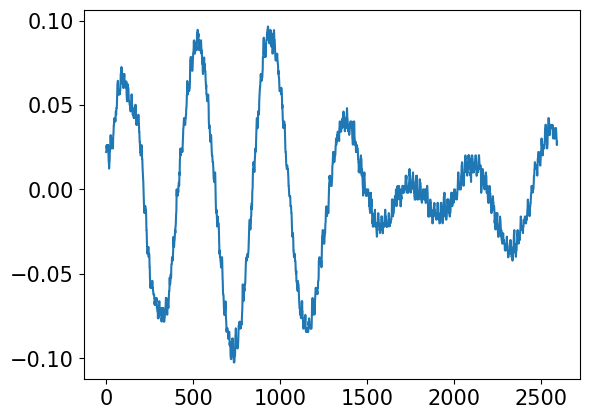

In [21]:
plt.plot(sourse.kiritori2(sourse.import_data(80,10,1)[0], sourse.left, sourse.right)[1500:])

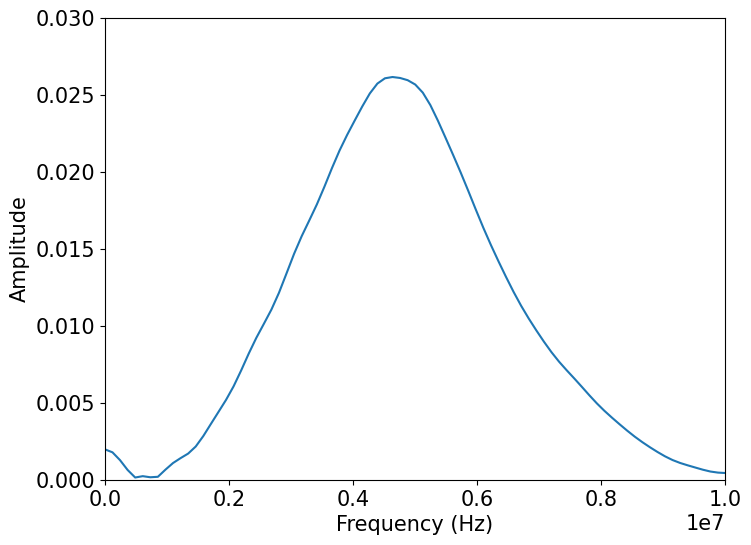

In [8]:
yf, freq = sourse.make_fftdata(sourse.kiritori2(sourse.import_data(0,10,1)[0], sourse.left, sourse.right), sourse.exp_dt)
sourse.image_ref(yf, freq)

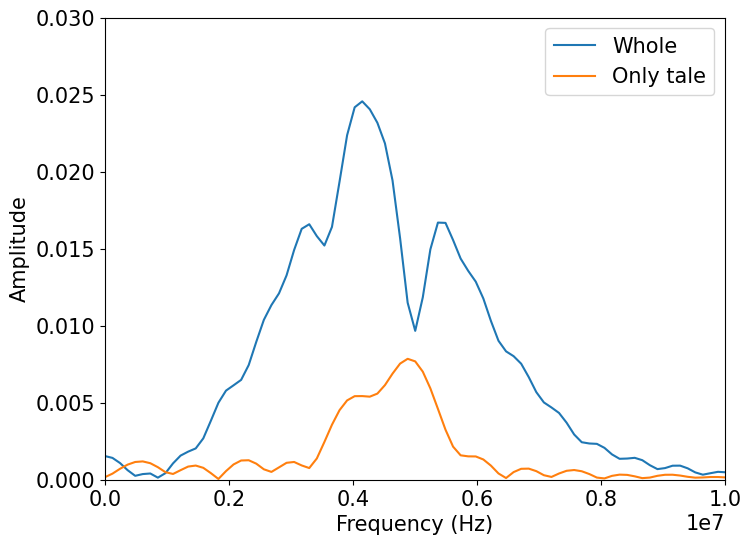

In [24]:
yf, tale, freq = sourse.make_fftdata_tale(sourse.kiritori2(sourse.import_data(80,10,1)[0], sourse.left, sourse.right), sourse.exp_dt, 1500)
sourse.image_many(yf, tale, freq)

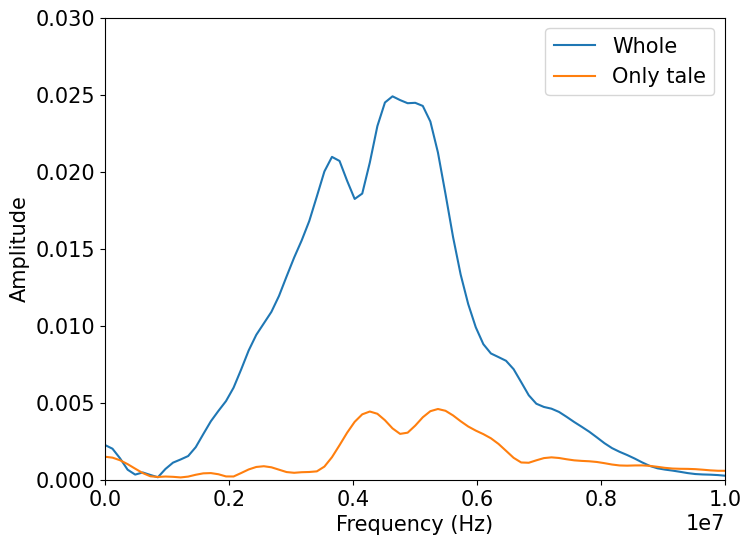

In [10]:
yf, tale, freq = sourse.make_fftdata_tale(sourse.kiritori2(sourse.import_data(90,10,2)[0], sourse.left, sourse.right), sourse.exp_dt, 1500)
sourse.image_many(yf, tale, freq)

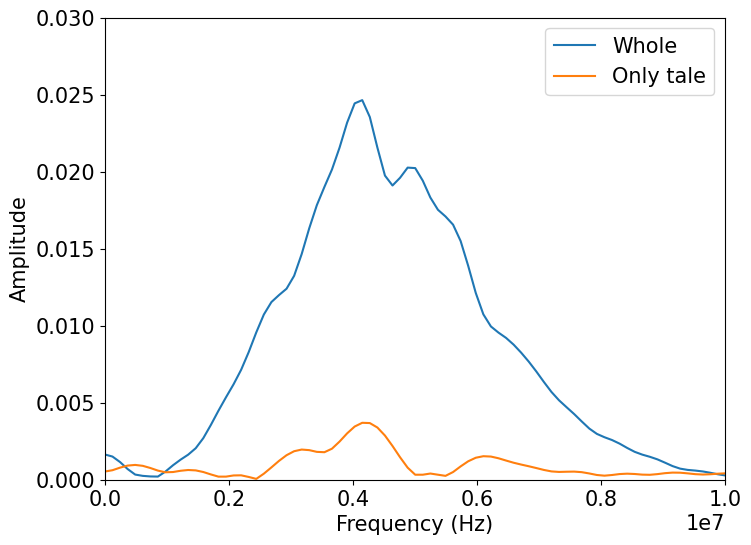

In [2]:
yf, tale, freq = sourse.make_fftdata_tale(sourse.kiritori2(sourse.import_data(100,10,1)[0], sourse.left, sourse.right), sourse.exp_dt, 1500)
sourse.image_many(yf, tale, freq)

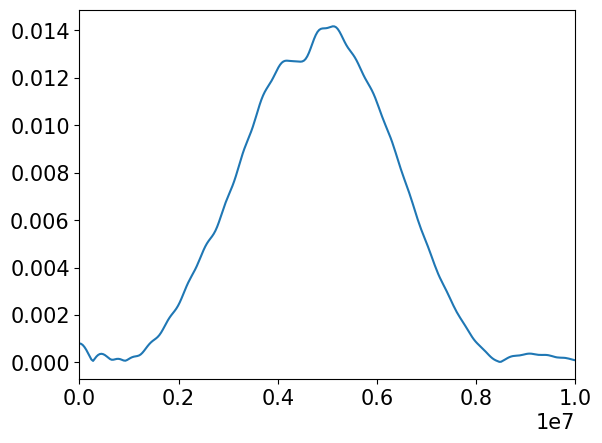

In [31]:
odd_data = np.loadtxt("odd_pitch125_depth20_1000.csv")
sim_yf, freq = sourse.make_fftdata(sourse.kiritori2(odd_data, int(sourse.left/2), int(sourse.right/2)), sourse25.dt)
plt.xlim(0, 10000000)
plt.plot(freq, sim_yf)


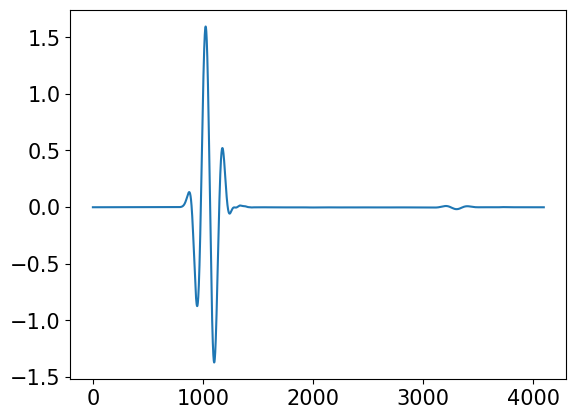

In [11]:
plt.plot(sourse.kiritori2(sourse.interpolate_sim_one(odd_data[0:-1]), sourse.left, sourse.right))

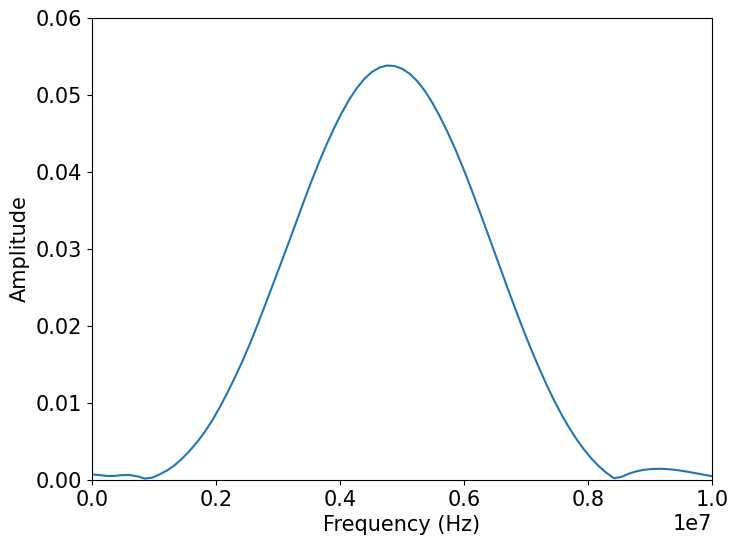

In [11]:
sim_data = np.loadtxt(r"C:\Users\Fujii Kotaro\project1\data_all\cupy_pitch125_depth0.csv")
sim_yf, freq = sourse.make_fftdata(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt)
sourse.image_ref_sim(sim_yf, freq)

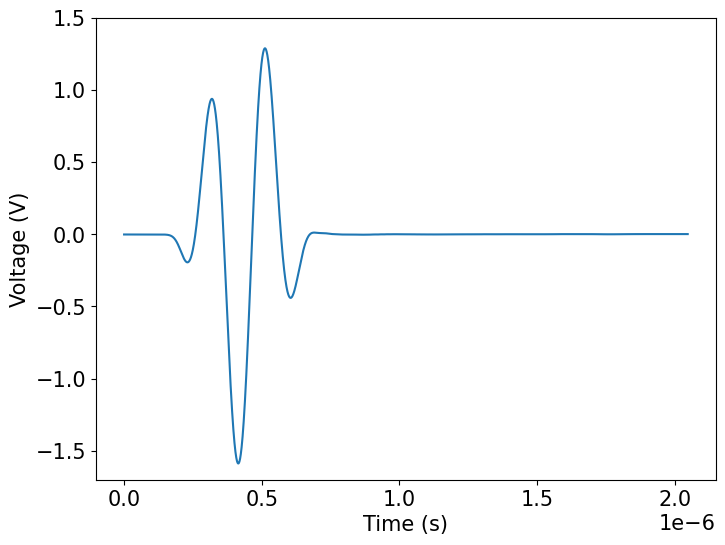

In [12]:
sourse.image_wave_sim(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt)

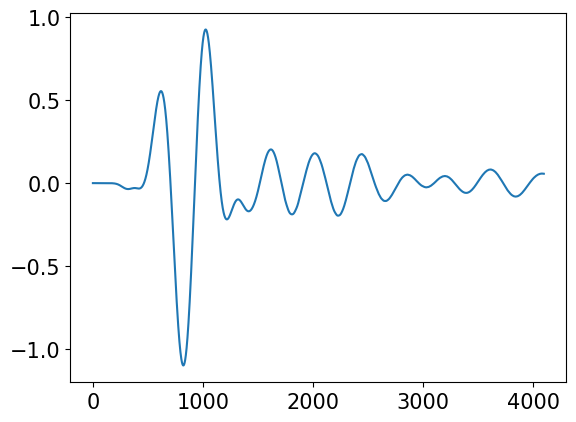

In [13]:
sim_data = np.loadtxt(r"C:\Users\Fujii Kotaro\project1\data_all\cupy_pitch125_depth20.csv")
plt.plot(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right))

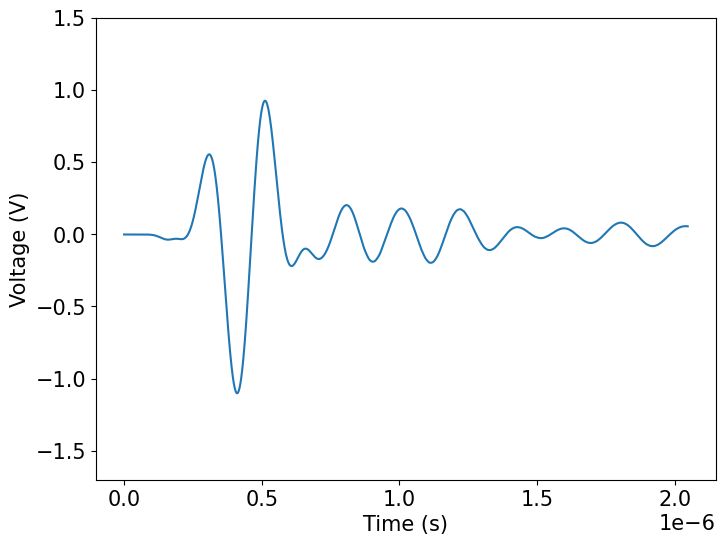

In [14]:
sourse.image_wave_sim(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt)

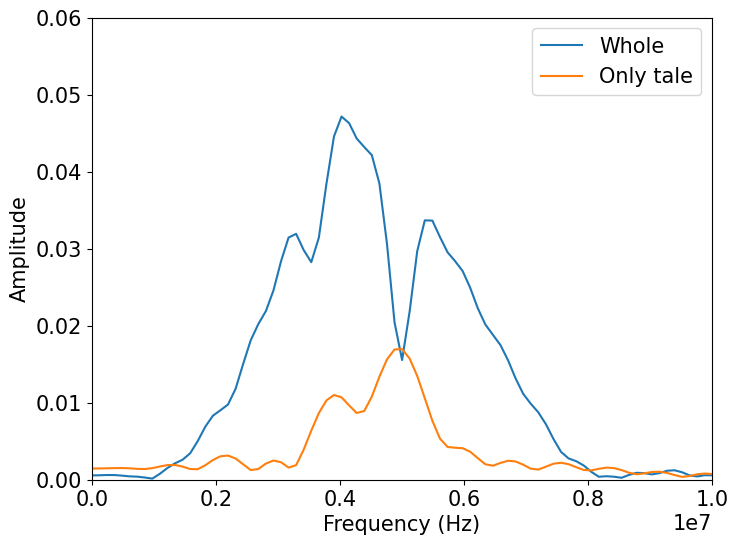

In [15]:

sim_yf, tale, freq = sourse.make_fftdata_tale(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt, 1500)
sourse.image_many_sim(sim_yf, tale,freq)

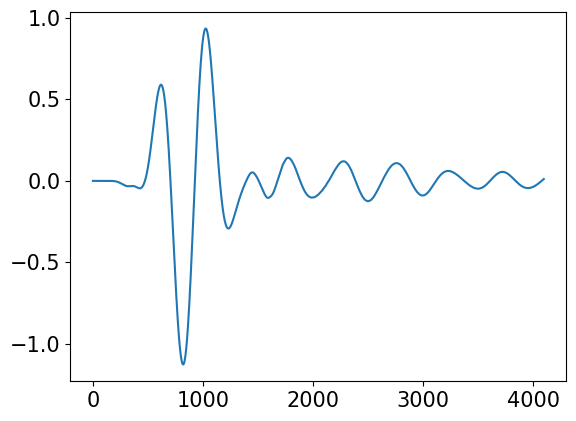

In [17]:
sim_data = np.loadtxt(r"C:\Users\Fujii Kotaro\project1\data_all\cupy_pitch150_depth20.csv")
plt.plot(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right))

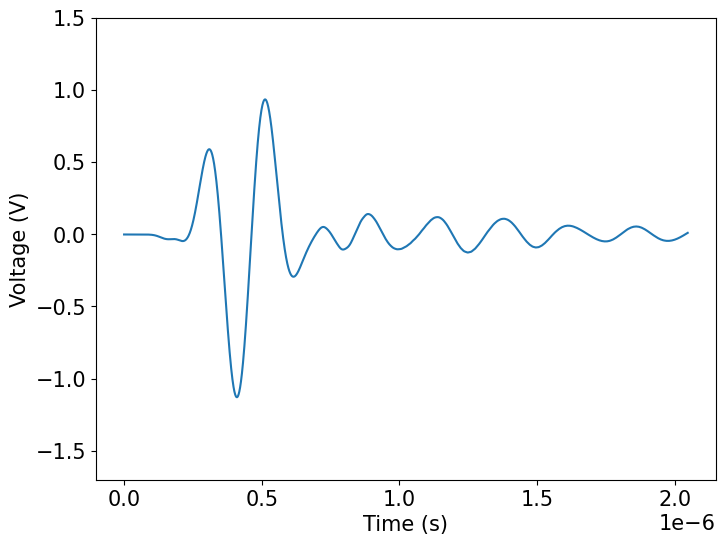

In [18]:

sourse.image_wave_sim(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt)

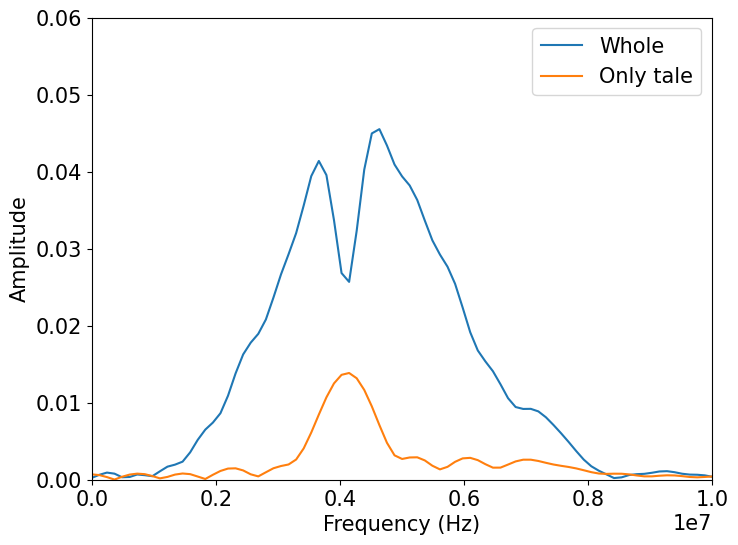

In [19]:
sim_yf, tale, freq = sourse.make_fftdata_tale(sourse.kiritori2(sourse.interpolate_sim_one(sim_data)[8000:], sourse.left, sourse.right), sourse.exp_dt, 1500)
sourse.image_many_sim(sim_yf, tale,freq)

In [ ]:
plt.rcParams["font.size"] = 15

In [ ]:
real_data_ref = sourse.kiritori2(sourse.import_data(0,10,1)[0], sourse.left, sourse.right)
real_yf_ref, freq = sourse.make_fftdata(real_data_ref, sourse.exp_dt)
sourse.image_ref(real_yf_ref, freq)

In [ ]:
fft_N = 2000
def kiritori2(data_sumple, left, right):
    datamaxhere = np.nanargmax(data_sumple)
    datamaxstart = datamaxhere - left
    datamaxend = datamaxhere + right
    return data_sumple[datamaxstart:datamaxend]


def make_fftdata(data, dt_sumple):
    howmanyzero = fft_N - len(data)
    data_fft = np.concatenate([np.zeros(int(howmanyzero / 2)), data, np.zeros(int(howmanyzero / 2))], 0)
    yf = np.fft.fft(data_fft) / (fft_N / 2)
    freq = np.linspace(0, 1.0 / dt_sumple, fft_N)
    return np.abs(yf), freq



In [ ]:
data = np.loadtxt(r"C:\Users\Fujii Kotaro\project1\cs_garion_Eywave_totyuu.csv")
plt.plot(data)

In [ ]:
yf, freq = make_fftdata(kiritori2(data, 150, 150), 0.040824829046386304)
plt.plot(freq, yf)


In [ ]:
y_length = 400  # x方向の長さ
mesh_length = 1.0  # メッシュ長さ
ny = int(y_length / mesh_length)  # how many mesh x coodinates
dy = y_length / ny  # mesh length
c = 10
epsilon = 1.0

dt = dy / c / np.sqrt(6)  # time mesh 
f = 1  # frequency
T = 1 / f  # period
lam = c / f  # lambda
k = 1 / lam  # wave number
n = T / dt  # 波が離散点上で何点か
# 入射波の設定
wn = 2.5  # 波数
wave4 = np.zeros(int(wn * n), dtype=float)
for ms in range(len(wave4)):
    wave2 = (1 - np.cos(2 * np.pi * f * dt * ms / wn)) / 2
    wave3 = np.sin(2 * np.pi * f * dt * ms)
    wave4[ms] = wave2 * wave3

In [ ]:
plt.plot(wave4)

In [ ]:
yf, freq = make_fftdata(wave4, 0.040824829046386304)
plt.plot(freq[:1999], yf)